# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is "linear" in its parameters where the input(s) can be a linear combination of the output. In other words, the input(s) and outputs form a linear relationship. The model finds a straight line or plane that minimizes the differences between predicted and actual values.
2. We interpret the coefficient for a one hot encoded variable as a categorical/qualitative value turned numeric. This is because for our model to work, all of our variables must be numeric, even if some of the most promising variables are categorical. The intercept represents the mean of the reference (dropped) group, and the other coefficients represent the difference from the reference group. 
3. Linear regression generally shouldn't be be used for classification. Classification is better suited for finding categorical target variables, whereas regression is better suited for finding numeric target variables. Since linear regression and classification serve distinct purposes, using regression for classification can be problematic when there's misclassification or an increased sensitivity to outliers.
4. A sign that a linear model is over-fitting is that it performs well on the training data but has poorer performance on the test data, which can be conveyed as a large discrepancy in train and test errors. Another sign is that excessively complex linear models have a high variance but low bias.
5. Multicolinearity occurs when a model is given two input variables that are highly correlated with each other. Since correlated variables have the tendency to cancel each other out, the model creates "mushy" predictions that are highly variable and unreliable. The two-stage least squares technique can solve this issue by using instrumental variables that don't correlate with the error, preventing the variable cancelling issue.
6. By transforming the independent variable x, through multiplication, squaring, or taking the log, we can incorporate nonlinear relationships between the target variable y and independent variable x. 
7. The slope coefficient in a linear regression represents the rate of change in y after every one-unit increase in x. It also represents the directionality and can be either positive or negative.
8. k-fold cross validation describes the process of partitioning the data into K equally-sized sets, estimating the model's parameters on the complementary chunks, testing performance on the k-th chunk, and recording the performance for each chunk as accuracy or MSE. This process provides K estimates of a model's performance. The idea of a train/test split isn't too different from k-fold cross validation; data is split into equally-sized train and test splits, which the model's performance on each is recorded using accuracy or MSE. As a result, both train/test split and k-fold cross validation serve the general function of estimating performance.
9. The k in k-fold cross validation is typically selected based off bias and model variance. The bias-variance trade-off is a core consideration of how we build models. We want to choose a k based on the idea that as k increases, model variance increases and bias decreases. In other words, the optimal k value is dependent on the prediction environment.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [118]:
import numpy as np
import pandas as pd

df = pd.read_csv('./data/Q1_clean.csv', encoding='latin1')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [119]:
print(df.columns.tolist())

['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type', 'Room Type']


In [120]:
df.columns = df.columns.str.strip()

In [121]:
#1
averages = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print(averages)

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


Question 1: The most expensive borough on average is Manhattan.

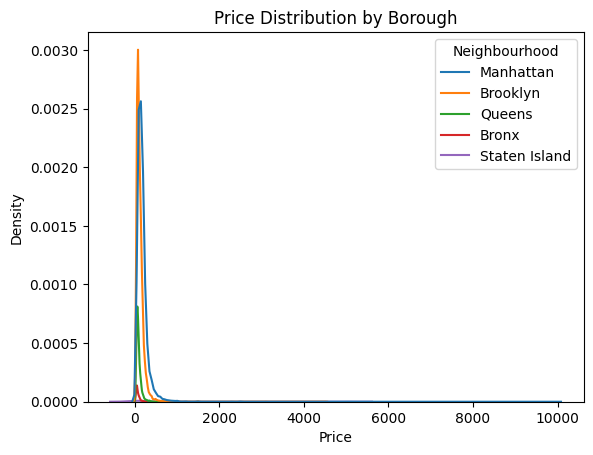

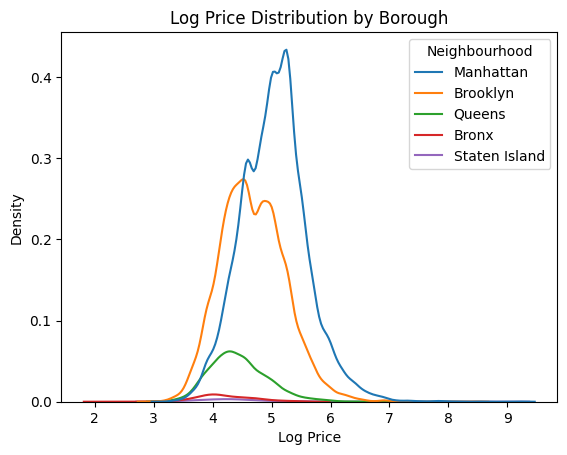

In [122]:
#1
import seaborn as sns
import matplotlib.pyplot as plt

# KDE of price
df['Log Price'] = np.log(df['Price'])

sns.kdeplot(df, x = 'Price', hue = 'Neighbourhood')

plt.xlabel("Price")
plt.title("Price Distribution by Borough")
plt.show()

# KDE of log price
sns.kdeplot(df, x = 'Log Price', hue = 'Neighbourhood')

plt.xlabel("Log Price")
plt.title("Log Price Distribution by Borough")
plt.show() 

In [123]:
#2
from sklearn.linear_model import LinearRegression

y = df['Price']
X = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 75.27649769584667


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


Question 2: I created a dummy variable by dropping the first category, which was the Bronx. Once the dummy variable was created, the estimated coefficient could represent the difference in the average price between each borough and reference group. The model intercept 125.94 represents the average price for the reference group, which was the Bronx. Thus, the conditional group averages are found by adding the model intercept and the coefficients of each variable. 

In [125]:
#3
y = df['Price']
X = df[['Review Scores Rating']]
model = LinearRegression()
model.fit(X, y)

print(f'Model Intercept: {model.intercept_}')
print(f'Slope Coefficient: {model.coef_[0]}')

Model Intercept: 60.878390657123816
Slope Coefficient: 1.0208266022674735


Question 3: The slope coefficient represents the rate of change; the output variable Price changes for every increase in the input variable Review Scores Rating. Since the slope coefficient is 1.02, that means that for every unit increase in rating results in price increasing by $1.02.

In [126]:
#4
y = df['Price']
X1 = df[['Review Scores Rating']]
model_single = LinearRegression().fit(X1, y)

X_dummy = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X2 = pd.concat([df[['Review Scores Rating']], X_dummy], axis=1)
model_combined = LinearRegression().fit(X2, y)

print(f'Single Linear Regression Coefficient: {model_single.coef_[0]}')
print(f'Multiple Linear Regression Coefficient: {model_combined.coef_[0]}')
print(f'Intercept: {model_combined.intercept_}')
pd.DataFrame({'variable': X2.columns, 'coefficient':model_combined.coef_ })

Single Linear Regression Coefficient: 1.0208266022674735
Multiple Linear Regression Coefficient: 1.081116483459853
Intercept: -23.81256101167321


,variable,coefficient
0,Review Scores Rating,1.081116
1,Brooklyn,51.704240
2,Manhattan,108.228737
3,Queens,21.694600
4,Staten Island,71.766552


Question 4: The coefficient on Review Scores Rating increased from 1.02 to 1.08 after adding neighborhood. This reveals that adding neighborhood caused the effect of ratings on price to be stronger when location is controlled. The averages in the single regression model didn't control neighborhood. However, the multiple linear regression holds neighborhoods constant when interpreting for the rating coefficient, and the neighborhood averages adjust for rating. Thus, the adjusted averages for neighborhood is independent of rating.

In [127]:
#5
X_dummy = pd.get_dummies(df['Neighbourhood'], dtype=int)
X_interactions = X_dummy.multiply(df['Review Scores Rating'], axis=0)

X = pd.concat([X_dummy, X_interactions], axis=1)
y = df['Price']

model = LinearRegression().fit(X, y)

pd.DataFrame({'neighborhood': X_dummy.columns, 'slope': model.coef_[len(X_dummy.columns):]})

,neighborhood,slope
0,Bronx,0.574311
1,Brooklyn,1.315476
2,Manhattan,1.304014
3,Queens,0.502017
4,Staten Island,-31.257437


Question 5: The slopes aren't similar across neighborhoods as they vary greatly. Notably, Staten Island's slope is the only one that is a negative extreme value. On the other hand, the slopes of Bronx and Queens are relatively similar, and the slopes of Brooklyn and Manhattan are similar.

In [128]:
#6: Cross validation for part 3
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

y = df['Price']
X = df[['Review Scores Rating']]

model = LinearRegression()

[...]

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

scores = cross_val_score(
    model,X,y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

mse_scores = -scores

print("MSE:", np.mean(mse_scores))

MSE: 22079.51235876914


In [129]:
#6: Cross validation for part 4
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

y = df['Price']
X_dummy = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X2 = pd.concat([df[['Review Scores Rating']], X_dummy], axis=1)

model = LinearRegression()

[...]

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

scores = cross_val_score(
    model,X2,y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

mse_scores = -scores

print("MSE:", np.mean(mse_scores))

MSE: 21074.09738730938


In [130]:
#6: Cross validation for part 5
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

X_dummy = pd.get_dummies(df['Neighbourhood'], dtype=int)
X_interactions = X_dummy.multiply(df['Review Scores Rating'], axis=0)
X = pd.concat([X_dummy, X_interactions], axis=1)
y = df['Price']

model = LinearRegression()

[...]

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

scores = cross_val_score(
    model,X,y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

mse_scores = -scores

print("MSE:", np.mean(mse_scores))

MSE: 21334.754813295105


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [131]:
import numpy as np
import pandas as pd

df2 = pd.read_csv('./data/cars_hw.csv', encoding='latin1')
df2.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


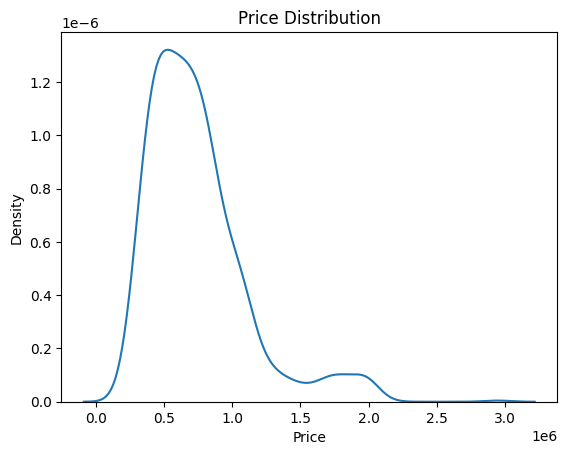

In [132]:
#1
print(df2['Price'].describe())

sns.kdeplot(df2['Price'])

plt.xlabel("Price")
plt.title("Price Distribution")
plt.show()

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


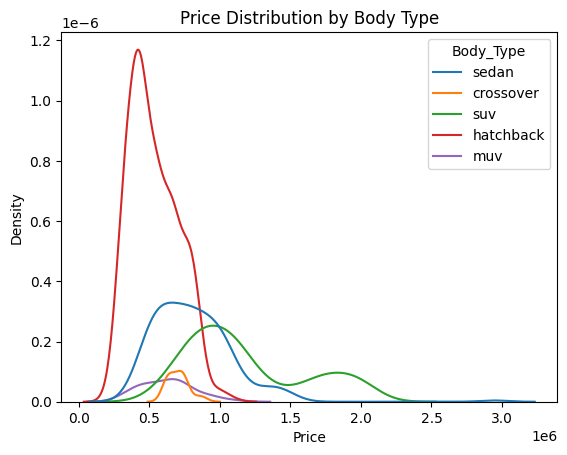

In [133]:
#1: Price by Body Type
print(df2.groupby('Body_Type')['Price'].describe())

sns.kdeplot(df2, x="Price", hue="Body_Type")

plt.xlabel("Price")
plt.title("Price Distribution by Body Type")
plt.show()

Question 1: Sedans are the most expensive on average, looking at the mean. SUV's have the highest variance based on the standard deviation number.

In [75]:
#2
y2 = df2['Price']
X2 = df2[['Seating_Capacity']]
model2 = LinearRegression()
model2.fit(X2, y2)

print(f'Model Intercept: {model2.intercept_}')
print(f'Slope Coefficient: {model2.coef_[0]}')

Model Intercept: 439032.0141018268
Slope Coefficient: 59267.9980367217


Question 2: The slope coefficient is 59267.998. This number represents that for every one unit increase in seating capacity, or every additional seat added, the price of the car increases by around 59,268 Rupees.

In [134]:
#2: One hot encoded variable
y2 = df2['Price']
X2 = pd.get_dummies(df2['Seating_Capacity'], drop_first=True, dtype=int)
model2 = LinearRegression()
model2.fit(X2, y2)

print(f'Model intercept: {model2.intercept_}')
pd.DataFrame({'variable':X2.columns, 'coefficient':model2.coef_ })

Model intercept: 188000.00000000163


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


Question 2 continued: The relationship isn't linear. The relationship is demonstrated by the price jumps in between each seat count. The six seating capacity variable adds a large price amount that is unusual compared to the other variables.

In [135]:
#3
df2['Age'] = 2026 - df2['Make_Year']
df2.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [136]:
#3
from sklearn.preprocessing import PolynomialFeatures

y2 = df2['Price']
X2 = df2[['Age']]

results = {}

for p in range(1,6):
    poly = PolynomialFeatures(degree=p)
    X_poly = poly.fit_transform(X2)

    kfold = KFold(n_splits=10, shuffle=True, random_state=100)
    scores = cross_val_score(
        model2,X_poly,y2,
        cv=kfold,
        scoring='neg_mean_squared_error'
        )

    mse = np.mean(-scores)
    results[p] = mse
    print(f'Average MSE: {mse}')

Average MSE: 97593991873.84819
Average MSE: 97788769710.30016
Average MSE: 97182824586.854
Average MSE: 96657152963.80292
Average MSE: 95734209144.59998


Question 3: The optimal number of powers of Age is 5 because it has the lowest MSE.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


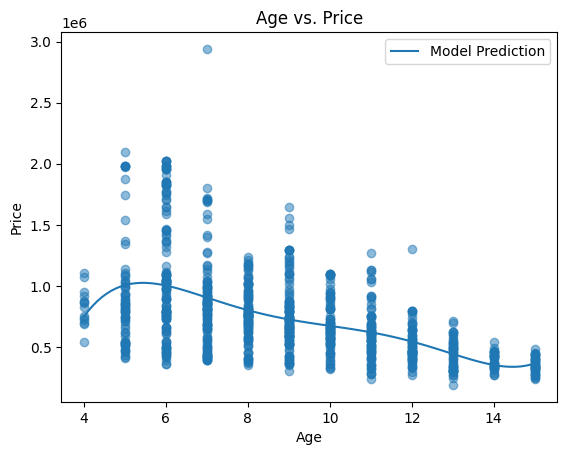

In [137]:
#4
import matplotlib.pyplot as plt
import numpy as np

poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X2)

model_poly = LinearRegression()
model_poly.fit(X_poly, y2)

age = np.linspace(df2['Age'].min(), df2['Age'].max(), 100).reshape (-1,1)
age_poly = poly.transform(age)

y_pred = model_poly.predict(age_poly)

plt.scatter(df2['Age'], df2['Price'], alpha=0.5)
plt.plot(age, y_pred, label="Model Prediction")
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Age vs. Price")
plt.legend()
plt.show()

Question 4: The model is pretty accurate to the patterns in the data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [138]:
import numpy as np
import pandas as pd

df3 = pd.read_csv('./data/heart_hw.csv', encoding='latin1')
df3.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [139]:
#1
control_mean = df3[df3['transplant'] == 'control']['y'].mean()
treatment_mean = df3[df3['transplant'] == 'treatment']['y'].mean()

ATE = treatment_mean - control_mean

print('Control Mean:', control_mean)
print('Treatment Mean:', treatment_mean)
print('ATE:', ATE)

Control Mean: 0.11764705882352941
Treatment Mean: 0.34782608695652173
ATE: 0.23017902813299232


Question 1: The ATE on three-year survival for heart transplant interventions is 0.23.

In [140]:
#2
df3['transplant_num'] = df3['transplant'].map({'control':0, 'treatment':1})

y3 = df3['y']
X3 = df3[['transplant_num']]
model3 = LinearRegression()
model3.fit(X3, y3)

print(f'Model Intercept: {model3.intercept_}')
print(f'Slope Coefficient: {model3.coef_[0]}')

Model Intercept: 0.11764705882352941
Slope Coefficient: 0.23017902813299232


Question 2: The model intercept is the same value as the control mean, and the transplant coefficient is the same as the ATE, or average treatment effect, value.

In [141]:
#3
y3 = df3['y']
X3 = df3[['transplant_num']]
model3 = LinearRegression()
model3.fit(X3, y3)

X3_combined = pd.concat([X3, df3['age']], axis=1)
model_combined = LinearRegression().fit(X3_combined, y3)

print(f'Single Linear Regression Coefficient: {model3.coef_[0]}')
print(f'Multiple Linear Regression Coefficient: {model_combined.coef_[0]}')
print(f'Intercept: {model_combined.intercept_}')

Single Linear Regression Coefficient: 0.23017902813299232
Multiple Linear Regression Coefficient: 0.26470168650367487
Intercept: 0.7019569721740946


Question 3: The coefficient on transplant increases to 0.265 compared to the previous value of 0.23 when age is controlled. The intercept represents the predicted average of the target y when all inputs are equal to 0. In this case, the intercept is the predicted y for a patient that is 0 years old and didn't receive treatment. The slope represents the increase in y that occurs when there's a one-unit increase on x; slope is represented by the single or multiple regression coefficient.

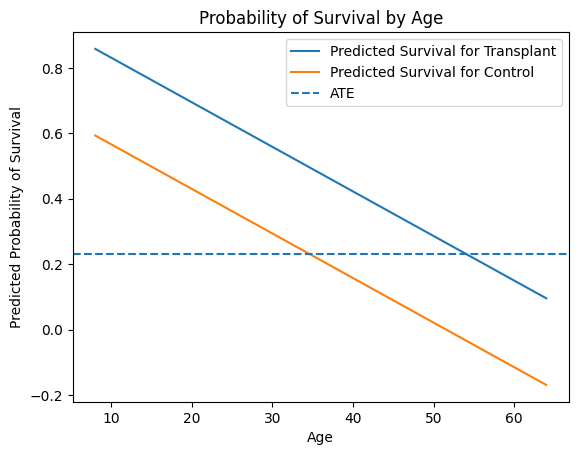

In [142]:
#3 continued
age_range = np.linspace(df3['age'].min(), df3['age'].max(), 100)

# Predicting the survival for the control group
X_control = pd.DataFrame({'transplant_num': 0, 'age': age_range})
y_control = model_combined.predict(X_control)

# Predicting the survival for the treatment group
X_treatment = pd.DataFrame({'transplant_num': 1, 'age': age_range})
y_treatment = model_combined.predict(X_treatment)

plt.plot(age_range, y_treatment, label='Predicted Survival for Transplant')
plt.plot(age_range, y_control, label='Predicted Survival for Control')

# ATE line
plt.axhline(y=0.23017902813299232, linestyle = '--', label='ATE')

plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Probability of Survival by Age')
plt.legend()
plt.show()

Question 3 continued: The ATE is over-estimating the impact of a transplant from age 55+. The ATE is under-estimating the impact of a transplant from ages 0 to 55.

In [143]:
#4
df3['transplant_age'] = df3['transplant_num'] * df3['age']

X4 = df3[['transplant_num', 'age', 'transplant_age']]
y3 = df3['y']
model_interaction = LinearRegression()
model_interaction.fit(X4, y3)

print(f'Transplant Coefficient: {model_interaction.coef_[0]}')
print(f'Age Coefficient: {model_interaction.coef_[1]}')
print(f'Interaction Coefficient: {model_interaction.coef_[2]}')
print(f'Intercept: {model_interaction.intercept_}')

Transplant Coefficient: 0.9077513885685893
Age Coefficient: -0.005524257506973695
Interaction Coefficient: -0.014590638256855278
Intercept: 0.35486517529945866


Question 4: Allowing age and transplant to interact helps us determine if the effect of the transplant is dependent on age. Our predictions are changed knowing that the age coefficient negatively affects the control group, illustrated in the negative value. Additionally, the interaction coefficient shows how a transplant's effect and age have a negative relationship. The main pattern is that as a patient gets older, the less likely the treatment is to work.

In [144]:
#5
y3 = df3['y']
X_single = df3[['transplant_num']]
X_combined = df3[['transplant_num', 'age']]
X_interaction = df3[['transplant_num', 'age', 'transplant_age']]

kfold = KFold(n_splits=10, shuffle=True, random_state=100)
model3 = LinearRegression()

# Model: Single
scores1 = cross_val_score(
    model,X_single,y3,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
print("Single Model Mean MSE:", np.mean(-scores1))

mse_scores = -scores

# Model: Combined
scores2 = cross_val_score(
    model,X_combined,y3,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
print("Combined Model Mean MSE:", np.mean(-scores2))

# Model: Interaction
scores3 = cross_val_score(
    model,X_interaction,y3,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
print("Interaction Model Mean MSE:", np.mean(-scores3))

Single Model Mean MSE: 0.1936638397901797
Combined Model Mean MSE: 0.18171967184387974
Interaction Model Mean MSE: 0.18067090272965364


Question 5: The last model, which controlled for transplant, age, and the interaction between transplant and age, had the lowest MSE. Thus, this model had the most accurate prediction. The second model had a MSE value that wasn't too far off, illustrating how age plays an important factor for predicting the treatment effect.

Question 6: My concerns regarding this model construction and deployment come from a lack of concern relating to other variables/factors besides age. The model was trained to predict a patient's survival based only on transplant, age, and the interaction between the two. Thus, it misses other factors such as additional health conditions, family medical history, etc. As a result, we can see how the model shouldn't be used as the ultimate predictor of transplant access.